# 🌱 TerraGuard Arequipa — Entrenamiento del modelo (Colab)

Random Forest para predecir **riesgo de contaminacion por metales pesados**
(Bajo / Medio / Alto) en la agricultura de Arequipa, cruzando:
- Vision (clorosis / necrosis en hoja)
- Geolocalizacion (distancia a foco minero)
- pH del suelo

**Metricas incluidas:** Matriz de confusion, Accuracy, Precision, Recall,
F1-Score y AUC ROC.

> Todo gratis. Ejecuta las celdas en orden (Runtime > Run all).

In [11]:
# 1) Instalacion (en Colab ya vienen casi todas)
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [13]:
# 2) Coordenadas reales de focos de riesgo en Arequipa + generador de datos
import numpy as np, pandas as pd

ZONAS_RIESGO = {
    "Cerro Verde (Cu/As)":  (-16.5389, -71.6017),
    "La Joya (As agua)":    (-16.5847, -71.9186),
    "Valle del Tambo (As)": (-17.0500, -71.7500),
}

def haversine_km(lat1, lon1, lat2, lon2):
    R=6371.0; p1,p2=np.radians(lat1),np.radians(lat2)
    dphi=np.radians(lat2-lat1); dl=np.radians(lon2-lon1)
    a=np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def dist_min(lat, lon):
    return min(haversine_km(lat,lon,mla,mlo) for mla,mlo in ZONAS_RIESGO.values())

def generar_dataset(n=600, seed=42):
    rng=np.random.default_rng(seed); filas=[]
    for _ in range(n):
        zona=rng.choice(list(ZONAS_RIESGO.keys()))
        bla,blo=ZONAS_RIESGO[zona]
        lat=bla+rng.normal(0,0.15); lon=blo+rng.normal(0,0.15)
        dist=dist_min(lat,lon)
        ph=np.clip(rng.normal(7.0,0.9),4.5,9.0)
        cerca=np.clip(1-dist/40,0,1)
        clor=np.clip(rng.normal(15+45*cerca,12),0,100)
        necr=np.clip(rng.normal(8+35*cerca,10),0,100)
        score=0.45*cerca+0.0045*clor+0.0045*necr+0.10*(ph<6.0)+rng.normal(0,0.06)
        riesgo=0 if score<0.35 else (1 if score<0.60 else 2)
        filas.append(dict(clorosis_pct=clor,necrosis_pct=necr,dist_mina_km=dist,
                          ph_suelo=ph,lat=lat,lon=lon,riesgo=riesgo))
    return pd.DataFrame(filas)

df=generar_dataset()
FEATURES=["clorosis_pct","necrosis_pct","dist_mina_km","ph_suelo"]
print(df.head())
print("\nDistribucion de clases (0=Bajo,1=Medio,2=Alto):")
print(df["riesgo"].value_counts().sort_index())

   clorosis_pct  necrosis_pct  dist_mina_km  ph_suelo        lat        lon  \
0     12.862344     11.525245     21.089097  7.846508 -16.694898 -71.489132   
1     64.611107     46.156621      5.281484  6.232260 -17.097436 -71.752520   
2     30.721496     37.961904     15.797256  7.331876 -16.514574 -72.047494   
3     45.448060     28.840821     11.286744  8.100287 -17.077729 -71.852139   
4     75.593863     31.075699      8.983029  7.387739 -16.529883 -71.856690   

   riesgo  
0       0  
1       2  
2       1  
3       2  
4       2  

Distribucion de clases (0=Bajo,1=Medio,2=Alto):
riesgo
0    110
1    231
2    259
Name: count, dtype: int64


In [5]:
# 3) Entrenamiento del Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X=df[FEATURES]; y=df["riesgo"]
X_tr,X_te,y_tr,y_te=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

rf=RandomForestClassifier(n_estimators=250,max_depth=8,min_samples_leaf=3,
                          class_weight="balanced",random_state=42)
rf.fit(X_tr,y_tr)
y_pred=rf.predict(X_te)
y_proba=rf.predict_proba(X_te)
print("Modelo entrenado ✓")

Modelo entrenado ✓


In [6]:
# 4) METRICAS: Accuracy, Precision, Recall, F1, AUC ROC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize

clases=sorted(y.unique())
y_te_bin=label_binarize(y_te,classes=clases)
auc=roc_auc_score(y_te_bin,y_proba,average="macro",multi_class="ovr")

print(f"Accuracy : {accuracy_score(y_te,y_pred):.4f}")
print(f"Precision: {precision_score(y_te,y_pred,average='macro'):.4f}")
print(f"Recall   : {recall_score(y_te,y_pred,average='macro'):.4f}")
print(f"F1-Score : {f1_score(y_te,y_pred,average='macro'):.4f}")
print(f"AUC ROC  : {auc:.4f}")
print("\n", classification_report(y_te,y_pred,
      target_names=["Bajo","Medio","Alto"]))

Accuracy : 0.8917
Precision: 0.9150
Recall   : 0.8784
F1-Score : 0.8929
AUC ROC  : 0.9611

               precision    recall  f1-score   support

        Bajo       1.00      0.82      0.90        22
       Medio       0.82      0.91      0.87        46
        Alto       0.92      0.90      0.91        52

    accuracy                           0.89       120
   macro avg       0.92      0.88      0.89       120
weighted avg       0.90      0.89      0.89       120



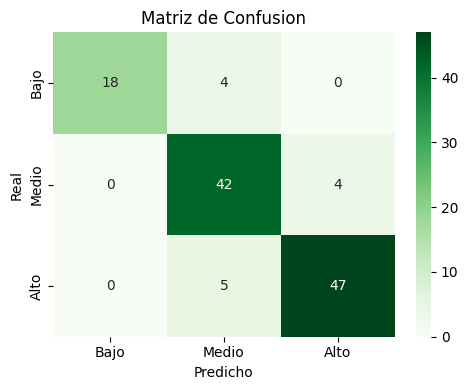

In [7]:
# 5) Matriz de confusion (visual)
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_te,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",
            xticklabels=["Bajo","Medio","Alto"],
            yticklabels=["Bajo","Medio","Alto"])
plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title("Matriz de Confusion")
plt.tight_layout(); plt.show()

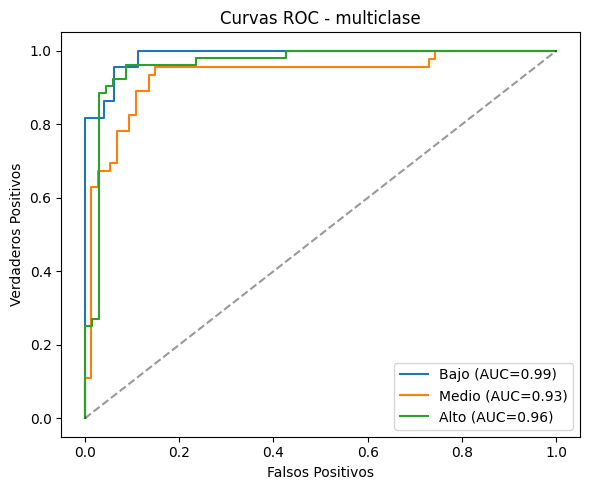

In [8]:
# 6) Curvas ROC por clase (one-vs-rest)
from sklearn.metrics import roc_curve, auc as auc_fn
plt.figure(figsize=(6,5))
for i,nombre in enumerate(["Bajo","Medio","Alto"]):
    fpr,tpr,_=roc_curve(y_te_bin[:,i],y_proba[:,i])
    plt.plot(fpr,tpr,label=f"{nombre} (AUC={auc_fn(fpr,tpr):.2f})")
plt.plot([0,1],[0,1],"k--",alpha=0.4)
plt.xlabel("Falsos Positivos"); plt.ylabel("Verdaderos Positivos")
plt.title("Curvas ROC - multiclase"); plt.legend(); plt.tight_layout(); plt.show()

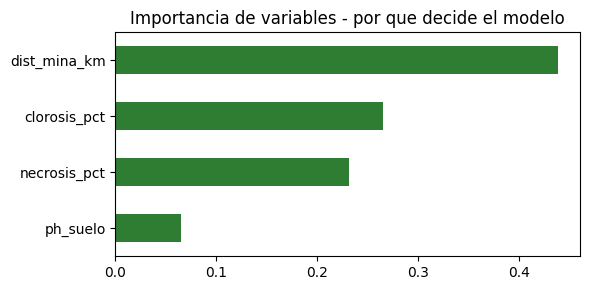

dist_mina_km    0.438830
clorosis_pct    0.265145
necrosis_pct    0.231369
ph_suelo        0.064656
dtype: float64


In [9]:
# 7) Importancia de variables (el gran argumento para el jurado)
imp=pd.Series(rf.feature_importances_,index=FEATURES).sort_values()
plt.figure(figsize=(6,3))
imp.plot.barh(color="#2e7d32")
plt.title("Importancia de variables - por que decide el modelo")
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False))

In [10]:
# 8) Guardar el modelo para usarlo en la app de Streamlit
import joblib
joblib.dump(rf,"modelo_rf.joblib")
print("Guardado modelo_rf.joblib  (descargalo y ponlo junto a app.py)")

Guardado modelo_rf.joblib  (descargalo y ponlo junto a app.py)


---
### Como conecta con la app
Este notebook entrena y valida el modelo con metricas. La app `app.py`
usa exactamente la misma logica (`src/model.py`) para predecir en vivo,
mas la vision con OpenCV, el mapa Folium y el reporte con Gemini.

**Nota honesta para el pitch:** los datos son sinteticos calibrados con
rangos de estudios reales de Arequipa (La Joya, Tambo, Cerro Verde). En
produccion se reemplazan por muestreo primario. El sistema es un
**tamizaje de priorizacion**, no reemplaza el laboratorio.